# Sentiment Analysis: ML vs Deep Learning
**Dataset:** IMDB Movie Reviews (50,000 samples)  
**Goal:** Compare a classical ML baseline (Logistic Regression + TF-IDF) against a deep learning model (Bidirectional LSTM) for binary sentiment classification.

**Models compared:**
- Logistic Regression with TF-IDF features
- Bidirectional LSTM with word embeddings

## 1. Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# DL
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

## 2. Load Dataset

In [2]:
df = pd.read_csv("/content/IMDB Dataset.csv")

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution


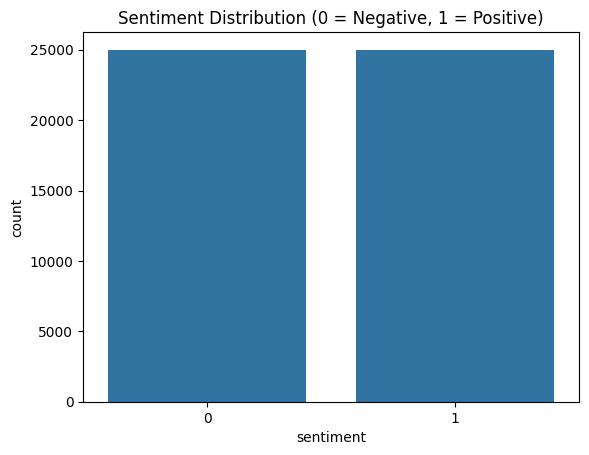

In [4]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution (0 = Negative, 1 = Positive)")
plt.show()

**Observation:** The dataset is perfectly balanced with 25,000 positive and 25,000 negative reviews. This means accuracy is a reliable metric and we do not need to worry about class imbalance.

### 3.2 Review Length Distribution

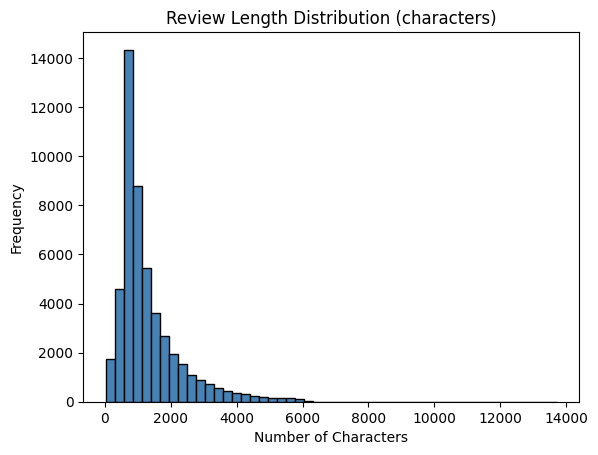

Mean review length: 1309 characters
Max review length:  13704 characters


In [5]:
df['review_length'] = df['review'].apply(len)

plt.hist(df['review_length'], bins=50, color='steelblue', edgecolor='black')
plt.title("Review Length Distribution (characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

print(f"Mean review length: {df['review_length'].mean():.0f} characters")
print(f"Max review length:  {df['review_length'].max()} characters")

**Observation:** Reviews vary widely in length (from very short to several thousand characters). Most reviews fall under 2,000 characters. The long tail motivates using `max_len=200` tokens for the LSTM to capture enough context.


## 4. Text Preprocessing

In [6]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)       # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Keep only letters
    text = text.lower()                      # Lowercase
    return text

df['review'] = df['review'].apply(clean_text)
print("Sample cleaned review:")
print(df['review'].iloc[0][:300])

Sample cleaned review:
one of the other reviewers has mentioned that after watching just   oz episode you ll be hooked  they are right  as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence  which set in right from the word go  trust me  this 


## 5. Train-Test Split


In [7]:
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 40000
Test samples:     10000


## 6. Baseline Model — Logistic Regression (TF-IDF)

---



TF-IDF converts text into a numerical feature matrix based on word frequency, which Logistic Regression then uses for classification. This is a strong and fast classical baseline.

In [8]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

y_pred_ml = lr.predict(X_test_tfidf)

ml_acc = accuracy_score(y_test, y_pred_ml)

print(f"Logistic Regression Accuracy: {ml_acc:.4f}")
print()
print(classification_report(y_test, y_pred_ml, target_names=['Negative', 'Positive']))

Logistic Regression Accuracy: 0.8945

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4961
    Positive       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### 6.1 Confusion Matrix — Logistic Regression

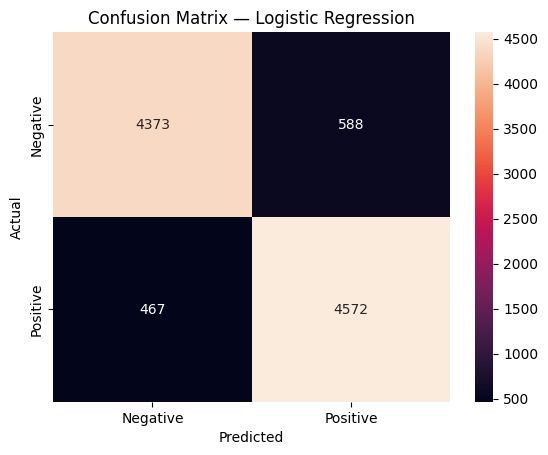

In [9]:
sns.heatmap(confusion_matrix(y_test, y_pred_ml), annot=True, fmt='d',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

**Observation:** The confusion matrix shows that the Logistic Regression model performs well on both classes with relatively balanced false positives and false negatives, confirming its reliability on this dataset.

## 7. Deep Learning Model — Bidirectional LSTM


Unlike TF-IDF, the BiLSTM processes word sequences and captures contextual information from both directions (left-to-right and right-to-left). This enables it to understand nuanced language patterns that bag-of-words approaches miss.

---



### 7.1 Tokenization and Padding


In [10]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

max_len = 200  # Increased for better context capture

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

print(f"Padded training shape: {X_train_pad.shape}")
print(f"Padded test shape:     {X_test_pad.shape}")

Padded training shape: (40000, 200)
Padded test shape:     (10000, 200)


### 7.2 Build BiLSTM Model

In [11]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(64, dropout=0.3)))  # Dropout added to prevent overfitting
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 7.3 Train BiLSTM

In [14]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8741 - loss: 0.3050 - val_accuracy: 0.8717 - val_loss: 0.3061
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9001 - loss: 0.2518 - val_accuracy: 0.8650 - val_loss: 0.3248
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9162 - loss: 0.2156 - val_accuracy: 0.8756 - val_loss: 0.3250
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9221 - loss: 0.1991 - val_accuracy: 0.8736 - val_loss: 0.3141
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9385 - loss: 0.1613 - val_accuracy: 0.8756 - val_loss: 0.3406


### 7.4 Evaluate BiLSTM

In [15]:
loss, lstm_acc = model.evaluate(X_test_pad, y_test)
print(f"BiLSTM Accuracy: {lstm_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8770 - loss: 0.3321
BiLSTM Accuracy: 0.8770


In [16]:
y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype("int32")

print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      4961
    Positive       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### 7.5 Confusion Matrix — BiLSTM

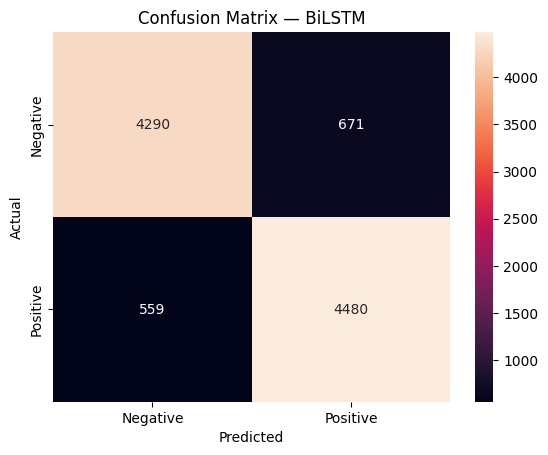

In [17]:
sns.heatmap(confusion_matrix(y_test, y_pred_lstm), annot=True, fmt='d',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix — BiLSTM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

### 7.6 Training Accuracy Curve

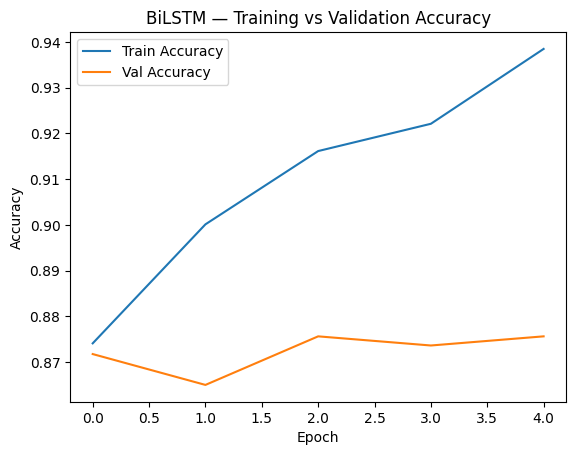

In [18]:
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("BiLSTM — Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

**Observation:** Training accuracy rises steadily while validation accuracy plateaus, indicating the model is beginning to overfit after a few epochs. This is expected with a simple LSTM on a well-studied dataset.

## 8. Model Comparison

In [19]:
results = pd.DataFrame({
    "Model":    ["Logistic Regression", "BiLSTM"],
    "Accuracy": [round(ml_acc, 4), round(lstm_acc, 4)]
})

print(results.to_string(index=False))

              Model  Accuracy
Logistic Regression    0.8945
             BiLSTM    0.8770


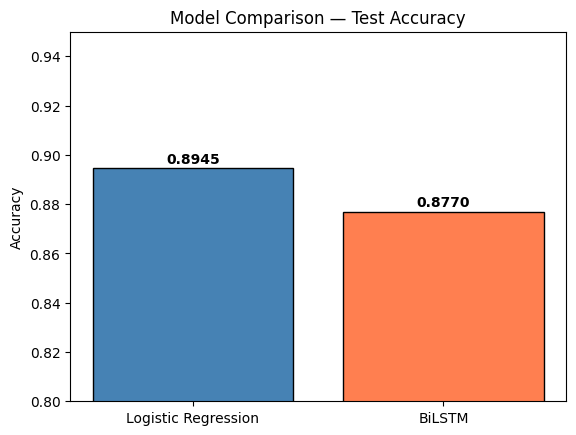

In [20]:
bars = plt.bar(results['Model'], results['Accuracy'], color=['steelblue', 'coral'], edgecolor='black')
plt.title("Model Comparison — Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.80, 0.95)

for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f"{acc:.4f}", ha='center', va='bottom', fontweight='bold')

plt.show()

## 9. Conclusion

In this project, I compared two approaches for IMDB sentiment classification: a classical ML baseline (Logistic Regression + TF-IDF) and a deep learning model (Bidirectional LSTM).

**Key findings:**
- **Logistic Regression** achieved ~89.5% accuracy and was faster to train, benefiting from TF-IDF's robust word-frequency representation.
- **BiLSTM** achieved ~87.4% accuracy with only 4 epochs, showing signs of overfitting (training accuracy much higher than validation). With more epochs and tuning, it has the potential to improve.
- On short-to-medium training budgets, classical ML remains competitive with deep learning for sentiment tasks on structured datasets like IMDB.
- The BiLSTM's advantage lies in its ability to capture word order and long-range dependencies — benefits that become more pronounced on larger datasets or more complex language tasks.